In [1]:
from pathlib import Path
import json
import pandas as pd

import cv2
import numpy as np
import torch
from ultralytics import YOLOE
from ultralytics.models.yolo.yoloe import YOLOEVPSegPredictor, YOLOEVPDetectPredictor

import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
def load_reference(ref_json_path: str):
    with open(ref_json_path, "r") as f:
        data = json.load(f)
    if isinstance(data, list):
        data = data[0]  # une seule référence pour ce premier test
    boxes = np.array(data["boxes"], dtype=np.float32)
    return data["image"], boxes

In [3]:
PROJECT_ROOT = Path.cwd().parent
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'manifests' / 'manifest.csv'
REFERENCE_PATH = PROJECT_ROOT / 'data' / 'ref.json'

INPUT_DIR = PROJECT_ROOT / 'data' / 'images' / 'orga_widecrop'
OUTPUT_DIR = PROJECT_ROOT / 'out' / 'predicted_crops'

usables = pd.read_csv(MANIFEST_PATH, index_col='id').dropna()

In [4]:
# target = PROJECT_ROOT / usables.iloc[232].chemin_wide
idxs = [0, 10, 100, 232, 980, 1000, 1001, 1295, 1536, 2016]
target = PROJECT_ROOT / usables.iloc[0].chemin_wide
target_images = [str(PROJECT_ROOT / usables.iloc[idx].chemin_wide) for idx in idxs]

ref_image, boxes = load_reference(REFERENCE_PATH)
n_boxes = len(boxes)
print(f"Reference : {ref_image}  ({n_boxes} box(es))")
print(f"Targets   : {target_images}")

visual_prompts = dict(
    bboxes=boxes,
    cls=np.zeros(n_boxes, dtype=int),  # une seule classe "aile" -> id 0
)

Reference : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_widecrop\Bombus_confusus\male\FR15ABOM150820018_P1.JPG  (1 box(es))
Targets   : ['c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_confusus\\male\\FR15ABOM150820018_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_confusus\\male\\FR15ABOM210821137_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_confusus\\worker\\CollecYvan10_P1.JPG', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_lapidarius\\male\\OPIE_Lapi_160720_S1.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_pratorum\\worker\\ABAURA8239_S3.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_pratorum\\worker\\ABAURA8240c_S3.jpg', 'c:\\Users\\Jules\\Documents\\IEES\\idmybee\\data\\images\\orga_widecrop\\Bombus_pratorum\\worker\\ABB.2017.20260_P1.JP

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = YOLOE("yoloe-11s-seg.pt")

results = model.predict(
    target_images,
    refer_image=ref_image,
    visual_prompts=visual_prompts,
    predictor=YOLOEVPSegPredictor,
    conf=0.05,
    imgsz=1024,
    device=device,
    verbose=False,
)

Ultralytics 8.4.92  Python-3.12.13 torch-2.12.1+cu130 CUDA:0 (NVIDIA GeForce RTX 2070, 8192MiB)
YOLOe-11s-seg summary (fused): 137 layers, 13,693,398 parameters, 1,857,958 gradients, 33.9 GFLOPs

0: 1024x1024 1 object0, 49.3ms
1: 1024x1024 1 object0, 49.3ms
2: 1024x1024 1 object0, 49.3ms
3: 1024x1024 1 object0, 49.3ms
4: 1024x1024 2 object0s, 49.3ms
5: 1024x1024 2 object0s, 49.3ms
6: 1024x1024 1 object0, 49.3ms
7: 1024x1024 1 object0, 49.3ms
8: 1024x1024 1 object0, 49.3ms
9: 1024x1024 2 object0s, 49.3ms
Speed: 14.9ms preprocess, 49.3ms inference, 3.1ms postprocess per image at shape (1, 3, 1024, 1024)



1 détection(s) sur l'image cible :
  [0] bbox=[1743.0, 1510.6, 3037.8, 2021.6]  conf=0.913

1 détection(s) sur l'image cible :
  [0] bbox=[1778.2, 1536.2, 3188.2, 2110.1]  conf=0.865

1 détection(s) sur l'image cible :
  [0] bbox=[1775.4, 1457.5, 3109.0, 2036.1]  conf=0.834

1 détection(s) sur l'image cible :
  [0] bbox=[598.5, 415.6, 1676.7, 850.6]  conf=0.774

2 détection(s) sur l'image cible :
  [0] bbox=[680.0, 1878.0, 1491.0, 2217.1]  conf=0.515
  [1] bbox=[9.4, 1643.8, 655.3, 2867.3]  conf=0.064

2 détection(s) sur l'image cible :
  [0] bbox=[806.2, 716.0, 1621.4, 1122.6]  conf=0.680
  [1] bbox=[420.6, 1111.6, 1317.0, 1663.7]  conf=0.066

1 détection(s) sur l'image cible :
  [0] bbox=[305.0, 397.0, 616.6, 525.0]  conf=0.598

1 détection(s) sur l'image cible :
  [0] bbox=[698.2, 872.3, 1501.1, 1252.4]  conf=0.748

1 détection(s) sur l'image cible :
  [0] bbox=[818.0, 447.4, 1835.4, 967.4]  conf=0.394

2 détection(s) sur l'image cible :
  [0] bbox=[372.6, 360.5, 657.1, 477.0]  con

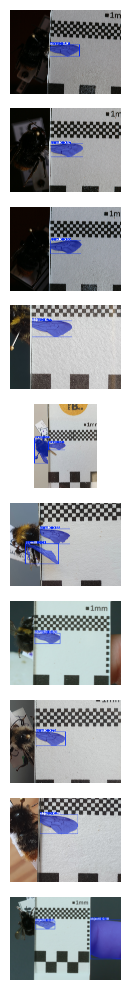

In [10]:
fig, axes = plt.subplots(len(results), 1, figsize=(2, len(results)))

for idx, r in enumerate(results):
    n_det = len(r.boxes) if r.boxes is not None else 0
    print(f"{n_det} détection(s) sur l'image cible :")
    for i in range(n_det):
        xyxy = r.boxes.xyxy[i].tolist()
        conf = float(r.boxes.conf[i])
        print(f"  [{i}] bbox={[round(v, 1) for v in xyxy]}  conf={conf:.3f}")

    annotated_img = r.plot()
    cv2.resize(annotated_img, None, fx=0.5, fy=0.5)
    axes[idx].imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('result.png', dpi=300)
plt.show()